# FarrahAI - Notebook 1: Adaptive OCR Evaluation

This notebook builds an adaptive OCR pipeline that:

- Tries a small menu of preprocessing variants (not every combination)
- Scores OCR outputs and selects the best per image
- Reuses the best method for similar images to save time
- Saves one text file per image and a full summary CSV
- Optionally extracts non-text figures as separate crops

This matches your requirement: do not force one preprocessing recipe for all images.


In [1]:
import sys
import os
import re
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from modules import preprocess as pp
import modules.ocr as ocr_mod

print('Libraries loaded')



# --- OCR wrapper with PaddleOCR fallback and caching ---

PADDLE_OCR_ENGINE = None
PADDLE_BROKEN = False
ACTIVE_OCR_ENGINE = None  # resolved engine when OCR_ENGINE = 'auto'


def _init_paddle_engine():
    global PADDLE_OCR_ENGINE, PADDLE_BROKEN
    if PADDLE_BROKEN:
        return None
    if PADDLE_OCR_ENGINE is not None:
        return PADDLE_OCR_ENGINE

    # Try to avoid oneDNN/pir runtime issues on some CPU builds
    os.environ.setdefault('FLAGS_use_mkldnn', '0')
    os.environ.setdefault('FLAGS_enable_mkldnn', '0')
    os.environ.setdefault('FLAGS_use_pir_api', '0')

    try:
        from paddleocr import PaddleOCR
    except Exception:
        PADDLE_BROKEN = True
        return None

    init_variants = [
        {'lang': 'en', 'use_textline_orientation': True},
        {'lang': 'en'},
        {}
    ]

    for kwargs in init_variants:
        try:
            PADDLE_OCR_ENGINE = PaddleOCR(**kwargs)
            return PADDLE_OCR_ENGINE
        except Exception:
            continue

    PADDLE_BROKEN = True
    return None


def _extract_with_paddle(image_path: str) -> dict:
    engine = _init_paddle_engine()
    if engine is None:
        raise RuntimeError('PaddleOCR unavailable')

    # PaddleOCR API: .ocr is deprecated, but still present
    result = engine.ocr(image_path)

    lines = []
    confidences = []
    boxes = []
    pages = result if result else []

    for page in pages:
        if page is None:
            continue
        for item in page:
            try:
                box = item[0]
                text, conf = item[1]
                lines.append(str(text))
                confidences.append(float(conf))
                boxes.append(box)
            except Exception:
                continue

    full_text = "\n".join(lines)
    avg_conf = float(sum(confidences) / len(confidences)) if confidences else 0.0

    return {
        'text': full_text,
        'confidence': round(avg_conf, 4),
        'boxes': boxes,
        'engine': 'paddleocr'
    }


def _extract_with_tesseract(image_path: str) -> dict:
    return ocr_mod.extract_text(image_path, engine='tesseract')


def resolve_engine(engine: str) -> str:
    # Resolve 'auto' to a concrete engine and cache it
    global ACTIVE_OCR_ENGINE
    if engine != 'auto':
        return engine
    if ACTIVE_OCR_ENGINE:
        return ACTIVE_OCR_ENGINE

    # Try PaddleOCR once; if it fails, fallback to tesseract
    try:
        if 'all_images' in globals() and all_images:
            _ = _extract_with_paddle(image_path=all_images[0])
            ACTIVE_OCR_ENGINE = 'paddleocr'
        else:
            ACTIVE_OCR_ENGINE = 'paddleocr'
    except Exception:
        ACTIVE_OCR_ENGINE = 'tesseract'

    return ACTIVE_OCR_ENGINE


def extract_text(image_path: str, engine: str = 'paddleocr') -> dict:
    engine = resolve_engine(engine)

    if engine == 'paddleocr':
        try:
            return _extract_with_paddle(image_path)
        except Exception:
            # Hard fallback if Paddle crashes at runtime
            return _extract_with_tesseract(image_path)

    if engine == 'tesseract':
        return _extract_with_tesseract(image_path)

    # unknown engine -> fallback
    return _extract_with_tesseract(image_path)


def evaluate_ocr(ground_truth_text: str, ocr_text: str, label: str = 'eval') -> dict:
    return ocr_mod.evaluate_ocr(ground_truth_text, ocr_text, label=label)


Libraries loaded


## Step 0: Configuration
Adjust these paths and settings once, then run the whole notebook.


In [2]:
# Dataset paths
RAW_DIR   = Path('../data/raw/AI_ML')
PDF_PATH  = None  # e.g., Path('../data/raw/AI_ML/DECAP737_MACHINE_LEARNING.pdf')

# Output folders
TEXT_OUT_DIR      = Path('../data/outputs/ocr_text/AI_ML')
CANDIDATE_IMG_DIR = Path('../data/processed/ocr_candidates/AI_ML')
FIGURE_OUT_DIR    = Path('../data/outputs/figures/AI_ML')

for d in [TEXT_OUT_DIR, CANDIDATE_IMG_DIR, FIGURE_OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# OCR engine preference
OCR_ENGINE = 'auto'   # 'auto' | 'paddleocr' | 'tesseract' (auto falls back safely)

# Candidate testing settings
PARALLEL_CANDIDATES = True
MAX_WORKERS = min(4, os.cpu_count() or 2)

# Adaptive reuse settings
FULL_SEARCH_FIRST_N     = 25   # run full candidate search for the first N images
NEIGHBOR_DIST_THRESHOLD = 0.25 # smaller = stricter similarity
VERIFY_NEIGHBOR         = True # if True, also try raw alongside predicted pipeline

# Figure extraction
EXTRACT_FIGURES = True
MIN_FIGURE_AREA_RATIO = 0.02  # 2% of page area


## Step 1: Helper Functions (Preprocessing + Scoring)
We define a small menu of pipelines, an OCR scoring function, and a similarity lookup.


In [3]:
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

PIPELINES = {
    # Keep menu small - do NOT brute force every combination
    'raw':       dict(clahe=None, denoise=None, threshold=False, deskew=False, morph=False),
    'mild':      dict(clahe=1.2, denoise=5,    threshold=False, deskew=False, morph=False),
    'binarize':  dict(clahe=1.4, denoise=5,    threshold=True,  deskew=False, morph=False),
    'deskew':    dict(clahe=1.6, denoise=7,    threshold=True,  deskew=True,  morph=False),
    'full':      dict(clahe=1.8, denoise=9,    threshold=True,  deskew=True,  morph=True),
}

CANDIDATE_ORDER = ['raw', 'mild', 'binarize', 'deskew', 'full']


def sanitize_filename(name: str) -> str:
    name = re.sub(r'\s+', '_', name.strip())
    name = re.sub(r'__+', '_', name)
    return name


def list_images(folder: Path) -> list:
    if not folder.exists():
        return []
    return sorted([str(p) for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS])


def pdf_to_images(pdf_path: Path, out_dir: Path, dpi: int = 200) -> list:
    # Convert PDF pages to images. Returns list of image paths.
    if pdf_path is None or not pdf_path.exists():
        return []
    out_dir.mkdir(parents=True, exist_ok=True)

    # Try PyMuPDF first
    try:
        import fitz  # PyMuPDF
        doc = fitz.open(str(pdf_path))
        paths = []
        for i in range(len(doc)):
            page = doc.load_page(i)
            pix = page.get_pixmap(dpi=dpi)
            base = sanitize_filename(pdf_path.stem)
            out_path = out_dir / f"{base}_page_{i+1:04d}.png"
            pix.save(str(out_path))
            paths.append(str(out_path))
        print(f"PDF to images via PyMuPDF: {len(paths)} pages")
        return paths
    except Exception:
        pass

    # Fallback to pdf2image
    try:
        from pdf2image import convert_from_path
        pages = convert_from_path(str(pdf_path), dpi=dpi)
        paths = []
        base = sanitize_filename(pdf_path.stem)
        for i, page in enumerate(pages):
            out_path = out_dir / f"{base}_page_{i+1:04d}.png"
            page.save(str(out_path), 'PNG')
            paths.append(str(out_path))
        print(f"PDF to images via pdf2image: {len(paths)} pages")
        return paths
    except Exception as e:
        print('PDF conversion skipped. Install pymupdf or pdf2image if needed.')
        print('Reason:', e)
        return []


def extract_image_features(gray: np.ndarray) -> np.ndarray:
    # Lightweight features for similarity lookup (values normalized to 0-1)
    if len(gray.shape) == 3:
        gray = cv2.cvtColor(gray, cv2.COLOR_BGR2GRAY)

    brightness = gray.mean() / 255.0
    contrast   = gray.std() / 128.0
    blur_val   = cv2.Laplacian(gray, cv2.CV_64F).var() / 1000.0

    edges = cv2.Canny(gray, 50, 150)
    edge_density = edges.mean() / 255.0

    median = cv2.medianBlur(gray, 3)
    diff = gray.astype(np.int16) - median.astype(np.int16)
    noise = np.mean(np.abs(diff)) / 50.0

    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    text_density = 1.0 - (bw.mean() / 255.0)  # black ratio

    feats = np.array([
        np.clip(brightness, 0, 1),
        np.clip(contrast,   0, 1),
        np.clip(blur_val,   0, 1),
        np.clip(edge_density, 0, 1),
        np.clip(noise, 0, 1),
        np.clip(text_density, 0, 1),
    ], dtype=np.float32)

    return feats


def preprocess_variant(image_path: str, pipeline_id: str) -> np.ndarray:
    cfg = PIPELINES[pipeline_id]
    img = pp.load_image(image_path)
    img = pp.to_grayscale(img)

    if cfg.get('clahe') is not None:
        img = pp.apply_clahe(img, clip_limit=cfg['clahe'])
    if cfg.get('denoise') is not None:
        img = pp.denoise(img, strength=int(cfg['denoise']))
    if cfg.get('threshold'):
        img = pp.threshold(img)
    if cfg.get('deskew'):
        img = pp.deskew(img, max_angle=10.0)
    if cfg.get('morph'):
        img = pp.morphological_cleanup(img)

    return img


def get_candidate_image_path(image_path: str, pipeline_id: str) -> str:
    base = sanitize_filename(Path(image_path).stem)
    out_dir = CANDIDATE_IMG_DIR / base
    out_dir.mkdir(parents=True, exist_ok=True)

    if pipeline_id == 'raw':
        return image_path

    out_path = out_dir / f"{base}__{pipeline_id}.png"
    if not out_path.exists():
        img = preprocess_variant(image_path, pipeline_id)
        cv2.imwrite(str(out_path), img)
    return str(out_path)


def score_ocr_output(text: str, confidence: float) -> float:
    # Heuristic score when no ground truth exists
    if text is None:
        return 0.0
    t = text.strip()
    if not t:
        return 0.0

    length = len(t)
    word_count = len(t.split())
    alpha_ratio = sum(ch.isalpha() for ch in t) / max(length, 1)

    length_score = min(length / 500.0, 1.0)
    word_score   = min(word_count / 80.0, 1.0)

    short_penalty = 0.15 if length < 40 else 0.0

    score = (0.55 * confidence) + (0.25 * word_score) + (0.15 * length_score) + (0.05 * alpha_ratio) - short_penalty
    return float(max(score, 0.0))


def run_candidate(image_path: str, pipeline_id: str, engine: str = OCR_ENGINE) -> dict:
    cand_path = get_candidate_image_path(image_path, pipeline_id)
    ocr_res = extract_text(cand_path, engine=engine)
    score = score_ocr_output(ocr_res.get('text', ''), ocr_res.get('confidence', 0.0))

    return {
        'pipeline': pipeline_id,
        'image_path': image_path,
        'candidate_path': cand_path,
        'text': ocr_res.get('text', ''),
        'confidence': ocr_res.get('confidence', 0.0),
        'engine': ocr_res.get('engine', engine),
        'score': score,
        'boxes': ocr_res.get('boxes', [])
    }


def run_candidates_for_image(image_path: str, pipelines: list, engine: str = OCR_ENGINE) -> list:
    results = []
    engine = resolve_engine(engine)

    # PaddleOCR is heavy and not thread-safe in some builds
    use_parallel = PARALLEL_CANDIDATES and len(pipelines) > 1 and engine != 'paddleocr'

    if use_parallel:
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
            futures = {ex.submit(run_candidate, image_path, p, engine): p for p in pipelines}
            for fut in as_completed(futures):
                results.append(fut.result())
    else:
        for p in pipelines:
            results.append(run_candidate(image_path, p, engine))
    return results


def choose_best_result(results: list) -> dict:
    return sorted(results, key=lambda r: r['score'], reverse=True)[0]


def nearest_pipeline(features: np.ndarray, memory: list, max_dist: float) -> tuple:
    if not memory:
        return (None, None)
    feats = np.stack([m['features'] for m in memory], axis=0)
    dists = np.linalg.norm(feats - features, axis=1)
    idx = int(np.argmin(dists))
    if dists[idx] <= max_dist:
        return (memory[idx]['pipeline'], float(dists[idx]))
    return (None, float(dists[idx]))


def profile_based_candidates(features: np.ndarray) -> list:
    # Keep it simple: always start from the small menu
    return CANDIDATE_ORDER.copy()


## Step 2: Quick Test on 1-2 Images (Optional)
Use this for inspection and CER/WER on a small sample.


In [4]:
all_images = list_images(RAW_DIR)
print('Total images:', len(all_images))

SAMPLE_IMAGE_PATHS = all_images[:2]  # adjust manually if needed
print('Sample images:', SAMPLE_IMAGE_PATHS)

# Optional ground truth dict (only if you have it)
# Keys must match image filename stem
GROUND_TRUTH = {
    # 'DECAP737_MACHINE_LEARNING_pages-to-jpg-0003': 'correct text here',
}

for img_path in SAMPLE_IMAGE_PATHS:
    base = Path(img_path).stem
    print('===', base, '===')
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    features = extract_image_features(img)
    pipelines = profile_based_candidates(features)
    results = run_candidates_for_image(img_path, pipelines)
    best = choose_best_result(results)

    print('Best pipeline:', best['pipeline'])
    print('Score:', round(best['score'], 4), '| Confidence:', best['confidence'])
    print('Text preview:', best['text'][:300])

    # If ground truth exists, compute CER/WER for best vs raw
    gt = GROUND_TRUTH.get(base)
    if gt:
        raw_res = [r for r in results if r['pipeline'] == 'raw'][0]
        best_eval = evaluate_ocr(gt.lower(), best['text'])
        raw_eval  = evaluate_ocr(gt.lower(), raw_res['text'])
        print('CER/WER best:', best_eval)
        print('CER/WER raw :', raw_eval)


Total images: 187
Sample images: ['../data/raw/AI_ML/DECAP737_MACHINE LEARNING_pages-to-jpg-0001.jpg', '../data/raw/AI_ML/DECAP737_MACHINE LEARNING_pages-to-jpg-0002.jpg']
=== DECAP737_MACHINE LEARNING_pages-to-jpg-0001 ===


Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
/home/harsh/Desktop/CUK/FarrahAI/farrahai_env/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/harsh/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/harsh/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownl

Best pipeline: raw
Score: 0.5383 | Confidence: 0.7925
Text preview: Machine Learning DECAP737 Edited by Dr. V Devenderan (OVELY | ROFESSIONAL (UNIVERSITY
=== DECAP737_MACHINE LEARNING_pages-to-jpg-0002 ===


[2026-04-14 21:06:07,817] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0002.jpg
[2026-04-14 21:06:07,880] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0002.jpg | shape: (3300, 2550, 3)
[2026-04-14 21:06:07,907] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0002.jpg | shape: (3300, 2550, 3)
[2026-04-14 21:06:07,923] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0002.jpg | shape: (3300, 2550, 3)
[2026-04-14 21:06:10,035] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0002.jpg | shape: (3300, 2550, 3)
[2026-04-14 21:06:10,062] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0002__mild.png
[2026-04-14 21:06:12,213] [    INFO] preprocess.py:155 - deskew: corrected 0.00°
[2026-04-14 21:06:12,262] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MA

Best pipeline: binarize
Score: 0.4951 | Confidence: 0.7062
Text preview: RX» [ILIOVELY 8 [PIROFESSIONAL Y [UNIVERSITY Machine Learning Edited By: Dr. V Devenderan


## Step 3: Adaptive OCR on Full Dataset
This is the main run. It:

- Chooses the best pipeline per image (small menu)
- Reuses the best pipeline for similar images
- Saves each OCR output into its own .txt file
- Saves a full summary CSV/JSON


In [5]:
# Optional: include PDF pages as additional images
pdf_images = pdf_to_images(PDF_PATH, CANDIDATE_IMG_DIR / 'pdf_pages') if PDF_PATH else []

all_images = list_images(RAW_DIR) + pdf_images
print('Total images (including PDF pages):', len(all_images))

memory = []
records = []

for idx, img_path in enumerate(all_images, 1):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print('Skipping unreadable image:', img_path)
        continue

    features = extract_image_features(img)

    # Decide candidate list
    if idx <= FULL_SEARCH_FIRST_N:
        pipelines = profile_based_candidates(features)
    else:
        guess, dist = nearest_pipeline(features, memory, NEIGHBOR_DIST_THRESHOLD)
        if guess and VERIFY_NEIGHBOR:
            pipelines = [guess, 'raw']
        elif guess:
            pipelines = [guess]
        else:
            pipelines = profile_based_candidates(features)

    results = run_candidates_for_image(img_path, pipelines)
    best = choose_best_result(results)

    # Save text output (sanitize filename)
    base = sanitize_filename(Path(img_path).stem)
    text_path = TEXT_OUT_DIR / f"{base}.txt"
    text_path.write_text(best['text'], encoding='utf-8')

    # Optional: extract figures (non-text regions)
    if EXTRACT_FIGURES:
        try:
            boxes = best.get('boxes', [])
            if not boxes:
                # Fallback to tesseract boxes if available
                try:
                    import pytesseract
                    from PIL import Image
                    data = pytesseract.image_to_data(Image.open(img_path), output_type=pytesseract.Output.DICT)
                    boxes = []
                    for i, txt in enumerate(data['text']):
                        if txt.strip():
                            x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
                            boxes.append((x, y, w, h))
                except Exception:
                    boxes = []

            if boxes:
                # Convert PaddleOCR box format to rectangles if needed
                rects = []
                for b in boxes:
                    if isinstance(b, (list, tuple)) and len(b) == 4 and isinstance(b[0], (list, tuple)):
                        xs = [p[0] for p in b]
                        ys = [p[1] for p in b]
                        x, y = int(min(xs)), int(min(ys))
                        w, h = int(max(xs) - min(xs)), int(max(ys) - min(ys))
                        rects.append((x, y, w, h))
                    elif isinstance(b, (list, tuple)) and len(b) == 4:
                        rects.append(tuple(map(int, b)))

                gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                color = cv2.imread(img_path)
                mask = np.zeros_like(gray)
                for x, y, w, h in rects:
                    cv2.rectangle(mask, (x, y), (x + w, y + h), 255, -1)

                _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
                bw = cv2.bitwise_and(bw, cv2.bitwise_not(mask))

                contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                h_img, w_img = gray.shape[:2]
                min_area = int(h_img * w_img * MIN_FIGURE_AREA_RATIO)
                fig_count = 0
                for c in contours:
                    x, y, w, h = cv2.boundingRect(c)
                    area = w * h
                    if area < min_area:
                        continue
                    if w < 40 or h < 40:
                        continue
                    crop = color[y:y+h, x:x+w]
                    fig_count += 1
                    fig_path = FIGURE_OUT_DIR / f"{base}__fig_{fig_count:02d}.png"
                    cv2.imwrite(str(fig_path), crop)
        except Exception:
            pass

    # Store memory for similarity reuse
    memory.append({'features': features, 'pipeline': best['pipeline']})

    # Log record
    records.append({
        'image': img_path,
        'best_pipeline': best['pipeline'],
        'score': best['score'],
        'confidence': best['confidence'],
        'engine': best['engine'],
        'text_file': str(text_path)
    })

    if idx % 10 == 0:
        print(f"Processed {idx}/{len(all_images)}")

# Save summary
summary_df = pd.DataFrame(records)
summary_csv = TEXT_OUT_DIR / 'ocr_summary.csv'
summary_json = TEXT_OUT_DIR / 'ocr_summary.json'
summary_df.to_csv(summary_csv, index=False)
summary_json.write_text(json.dumps(records, indent=2), encoding='utf-8')

print('Saved summary:', summary_csv)
print('Saved summary:', summary_json)


Total images (including PDF pages): 187


[2026-04-14 21:06:19,930] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0001.jpg
[2026-04-14 21:06:19,935] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0001__mild.png
[2026-04-14 21:06:19,938] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0001__binarize.png
[2026-04-14 21:06:19,946] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0001__deskew.png
[2026-04-14 21:06:21,199] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0001__full.png
[2026-04-14 21:06:26,871] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0002.jpg
[2026-04-14 21:06:26,873] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0002__binarize.png
[2026-04-14 21:06:26,874] [    INFO] ocr.py:126 - Running OCR [tesseract] on: 

Processed 10/187


[2026-04-14 21:09:11,800] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0011.jpg | shape: (3509, 2481, 3)
[2026-04-14 21:09:11,820] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0011.jpg | shape: (3509, 2481, 3)
[2026-04-14 21:09:11,838] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0011.jpg | shape: (3509, 2481, 3)
[2026-04-14 21:09:13,738] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0011__mild.png
[2026-04-14 21:09:17,037] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0011.jpg | shape: (3509, 2481, 3)
[2026-04-14 21:09:18,992] [    INFO] preprocess.py:155 - deskew: corrected 0.00°
[2026-04-14 21:09:19,047] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0011__full.png
[2026-04-14 21:09:22,593] [    INFO] preprocess.py:155 - deskew: corrected 0.00°
[2

Processed 20/187


...

Processed 170/187


[2026-04-14 21:28:09,130] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0172.jpg
[2026-04-14 21:28:09,130] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0172.jpg
[2026-04-14 21:28:12,410] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0173.jpg
[2026-04-14 21:28:12,410] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0173.jpg
[2026-04-14 21:28:15,526] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0174.jpg
[2026-04-14 21:28:15,527] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0174.jpg
[2026-04-14 21:28:19,804] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0175.jpg
[2026-04-14 21:28:19,832] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0175.jpg 

Processed 180/187


[2026-04-14 21:29:03,853] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0182.jpg
[2026-04-14 21:29:03,855] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0182.jpg
[2026-04-14 21:29:11,777] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0183.jpg
[2026-04-14 21:29:11,778] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0183.jpg
[2026-04-14 21:29:15,160] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE LEARNING_pages-to-jpg-0184.jpg
[2026-04-14 21:29:15,186] [    INFO] preprocess.py:36 - Loaded image: DECAP737_MACHINE LEARNING_pages-to-jpg-0184.jpg | shape: (3509, 2481, 3)
[2026-04-14 21:29:16,864] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE_LEARNING_pages-to-jpg-0184__mild.png
[2026-04-14 21:29:19,771] [    INFO] ocr.py:126 - Running OCR [tesseract] on: DECAP737_MACHINE 

Saved summary: ../data/outputs/ocr_text/AI_ML/ocr_summary.csv
Saved summary: ../data/outputs/ocr_text/AI_ML/ocr_summary.json


## Step 4: Quick Summary Charts


best_pipeline
raw         123
binarize     29
mild         19
deskew       11
full          5
Name: count, dtype: int64


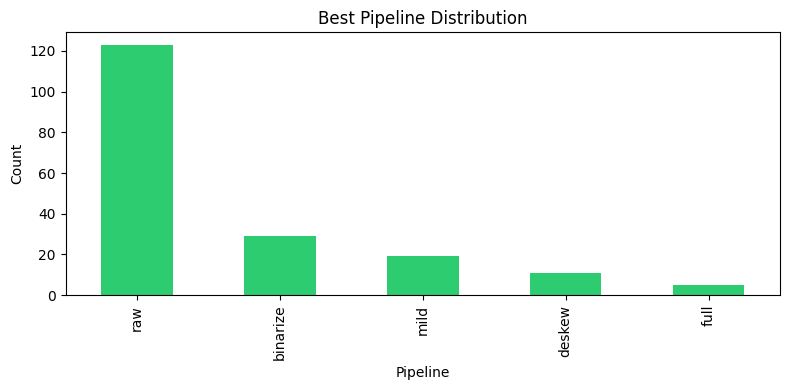

Average confidence: 0.907


In [6]:
summary_df = pd.read_csv(TEXT_OUT_DIR / 'ocr_summary.csv')

print(summary_df['best_pipeline'].value_counts())

plt.figure(figsize=(8, 4))
summary_df['best_pipeline'].value_counts().plot(kind='bar', color='#2ecc71')
plt.title('Best Pipeline Distribution')
plt.ylabel('Count')
plt.xlabel('Pipeline')
plt.tight_layout()
plt.show()

print('Average confidence:', round(summary_df['confidence'].mean(), 4))


In [ ]:
# --- CER/WER evaluation on selected files 

from pathlib import Path
import pandas as pd

TEXT_OUT_DIR = Path('../data/outputs/ocr_text/AI_ML')

GROUND_TRUTH = {
    'DECAP737_MACHINE_LEARNING_pages-to-jpg-0185': """Notes

Machine Learning

Answers for Self Assessment

1. D    2. A    3. A    4. B    5. C
6. B    7. A    8. B    9. C    10. C
11. C   12. D   13. A   14. A   15. B

Review Questions

1. Explain the concept of a perceptron and how it functions within an artificial neural network.
2. Discuss the importance of activation functions in artificial neural networks. Provide examples of commonly used activation functions and their characteristics.
3. Describe the backpropagation algorithm and its role in training artificial neural networks. Explain how gradient descent is utilized in backpropagation.
4. Compare and contrast feedforward neural networks and recurrent neural networks. Discuss the advantages and applications of each type.
5. Explain the architecture and working principles of convolutional neural networks (CNNs). Discuss their significance in image processing tasks such as image classification and object detection.
6. Describe the concept of regularization in neural networks. Discuss common regularization techniques used to prevent overfitting and improve model generalization.
7. Discuss the importance of hyperparameter tuning in neural networks. Explain different methods and strategies for finding optimal hyperparameter configurations.
8. Explain the concept of model evaluation in artificial neural networks. Discuss commonly used evaluation metrics and their significance in assessing model performance.
9. Discuss the challenges and limitations of artificial neural networks. Highlight specific areas where neural networks may face difficulties or exhibit limitations.
10. Describe the applications of artificial neural networks in real-world scenarios, such as natural language processing, time series analysis, or recommendation systems. Provide examples and discuss their effectiveness in these applications.

Further Readings

Madan Gopal, Applied Machine Learning, McGraw Hill Education, India, 2018.
S. N. Sivanandam, S. N. Deepa, Principles Of Soft Computing, Wiley Publications, Second Edition, 2011.
Rajasekaran, S., Pai, G. A. Vijayalakshmi, Neural Networks, Fuzzy Logic and Genetic Algorithm Synthesis And Applications, Prentice Hall of India, 2013.
N. P. Padhy, S. P. Simon, Soft Computing With Matlab Programming, Oxford University Press, 2015.

Web Links

https://www.javatpoint.com/artificial-neural-network
https://www.analyticsvidhya.com/blog/2021/05/beginners-guide-to-artificial-neural-network/
https://www.techopedia.com/definition/5967/artificial-neural-network-ann

LOVELY PROFESSIONAL UNIVERSITY
"""
}

# Evaluate
rows = []
for stem, gt in GROUND_TRUTH.items():
    txt_path = TEXT_OUT_DIR / f"{stem}.txt"
    if not txt_path.exists():
        print("Missing OCR text:", txt_path)
        continue

    ocr_text = txt_path.read_text(encoding='utf-8', errors='ignore')
    gt_norm = gt.lower().replace("\n", " ")
    eval_res = evaluate_ocr(gt_norm, ocr_text, label=stem)

    rows.append({
        "file": stem,
        "cer": eval_res["cer"],
        "wer": eval_res["wer"],
        "cer_%": eval_res["cer_%"],
        "wer_%": eval_res["wer_%"],
    })

df_eval = pd.DataFrame(rows)
display(df_eval)

[2026-04-14 21:40:22,543] [    INFO] ocr.py:227 - [DECAP737_MACHINE_LEARNING_pages-to-jpg-0185] CER: 9.46%  WER: 42.12%


,file,cer,wer,cer_%,wer_%
0,DECAP737_MACHINE_LEARNING_pages-to-jpg-0185,0.0946,0.4212,9.46,42.12
